In [1]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import VPtools as vp
import numpy as np
from pathlib import Path
import math

path_google = 'G:/Shared drives/'

def make_binary_model_O(p):
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galO_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galO_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label
def make_binary_model_B(p): # B star
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label


def make_binary_model_OB(p): # OB pair
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galO_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label

from pathlib import Path


In [2]:
def process_component(synth, continuum, wl, vrad, vsini):
    s = synth.doppler_shift(vrad).interp(wl).rot_int_cmj(vsini=vsini)
    c = continuum.doppler_shift(vrad).interp(wl).rot_int_cmj(vsini=vsini)
    return s, c
def get_tlusty_path_template(grid):
    grid = grid.upper()
    if grid == "B": return vp.tlusty.galB_path_name
    if grid == "O": return vp.tlusty.galO_path_name
    raise ValueError(f"Unknown grid {grid!r}")

def get_tlusty_model_name(grid, teff, logg, vturb):
    return get_tlusty_path_template(grid).format("vis", teff, logg, str(vturb))
def make_binary_model(p):
    v1, v2 = p.get("vturb1", p["vturb"]), p.get("vturb2", p["vturb"])
    m1 = get_tlusty_model_name(p["grid_1"], p["teff1"], p["logg1"], v1)
    m2 = get_tlusty_model_name(p["grid_2"], p["teff2"], p["logg2"], v2)

    model = vp.tlusty_binary(
        path_google, m1, m2,
        p["vsini1"], p["vsini2"], p["R2R1"],
        p["vrad1"], p["vrad2"]
    )

    label = (f"{m1}+{m2}\n"
             f"vrad=({p['vrad1']},{p['vrad2']}), "
             f"vsini=({p['vsini1']},{p['vsini2']}), "
             f"R2/R1={p['R2R1']}")

    return model, label

def make_binary_components(p):
    v1, v2 = p.get("vturb1", p["vturb"]), p.get("vturb2", p["vturb"])
    m1 = get_tlusty_model_name(p["grid_1"], p["teff1"], p["logg1"], v1)
    m2 = get_tlusty_model_name(p["grid_2"], p["teff2"], p["logg2"], v2)

    s1, c1 = vp.tlusty.read(path_google + m1)
    s2, c2 = vp.tlusty.read(path_google + m2)
    wl = s1.wl

    b1, bc1 = process_component(s1, c1, wl, p["vrad1"], p["vsini1"])
    b2, bc2 = process_component(s2, c2, wl, p["vrad2"], p["vsini2"])

    r2 = p["R2R1"]**2
    total_con = bc1.specI + bc2.specI * r2

    con1, con2 = bc1.specI / total_con, bc2.specI * r2 / total_con
    comp1 = vp.synth.Synth(wl, b1.specI / total_con + (1 - con1))
    comp2 = vp.synth.Synth(wl, b2.specI * r2 / total_con + (1 - con2))

    label1 = (rf"Component 1: $T_{{\rm eff}}={p['teff1']}$ K, "
              rf"$\log g={p['logg1']/100:.2f}$, "
              rf"$v\sin i={p['vsini1']}$, $v_r={p['vrad1']}$")

    label2 = (rf"Component 2: $T_{{\rm eff}}={p['teff2']}$ K, "
              rf"$\log g={p['logg2']/100:.2f}$, "
              rf"$v\sin i={p['vsini2']}$, $v_r={p['vrad2']}$")

    return comp1, comp2, label1, label2


def save_binary_model(obsname, params_B, component_1, component_2, model):
    folder = Path(r"G:\Shared drives\BinamicsOstars\TLUSTY Models") / obsname
    folder.mkdir(parents=True, exist_ok=True)

    p = params_B
    name1 = f"T{p['teff1']}G{p['logg1']}_v{p['vsini1']}_vr{p['vrad1']}.s"
    name2 = f"T{p['teff2']}G{p['logg2']}_v{p['vsini2']}_vr{p['vrad2']}.s"

    # VPtools Synth -> specpolFlow Spectrum
    empty = np.zeros_like(component_1.wl)
    spec1 = pol.Spectrum(wl=component_1.wl, specI=component_1.specI, specV=empty, specN1=empty, specN2=empty,specSig=empty)
    spec2 = pol.Spectrum(wl=component_2.wl, specI=component_2.specI, specV=empty, specN1=empty, specN2=empty,specSig=empty)
    binary = pol.Spectrum(wl=model.wl/10, specI=model.specI, specV=empty, specN1=empty, specN2=empty,specSig=empty)

    spec1.save(folder / name1)
    spec2.save(folder / name2)
    binary.save(folder / "binary_model.s")

    print(f"Saved to {folder}")

Found 3 observations for hd219634:
hd219634_1977051pnm_rn.s
hd219634_E_1737886pnm_rn.s
hd219634_E_1977051pnm_rn.s


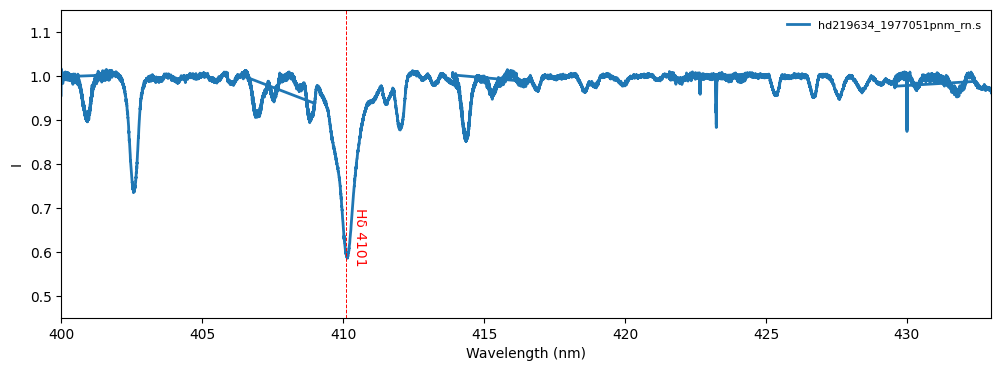

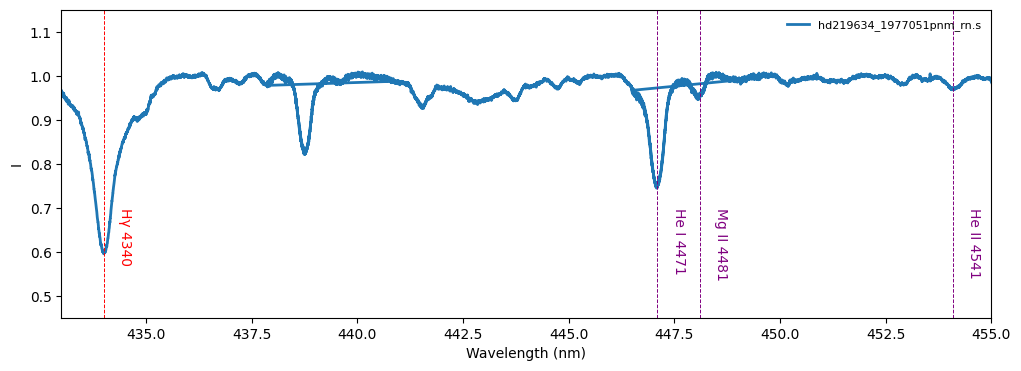

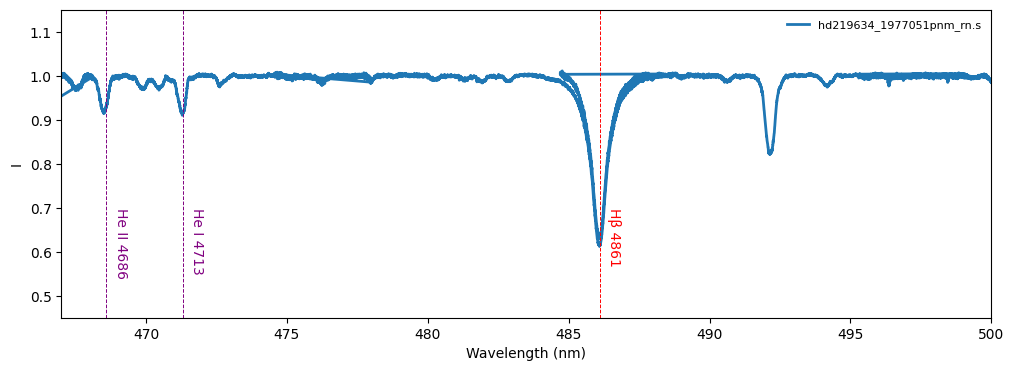

In [79]:
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")

hd = "hd219634"
obs = sorted([f.name for f in obs_folder.glob(f"{hd}*.s")])

print(f"Found {len(obs)} observations for {hd}:")
for f in obs:
    print(f)

windows = [(400, 433), (433, 455), (467, 500)]

lines_H = [
    (410.1, "Hδ 4101"),
    (434.0, "Hγ 4340"),
    (486.1, "Hβ 4861"),
]

lines_He = [
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
]

# Read spectra
spectra = [(f, pol.read_spectrum(obs_folder / f)) for f in obs]

# Plot all observations overlaid
for xmin, xmax in windows:
    fig, ax = plt.subplots(figsize=(12, 4))

    # for filename, spec in spectra:
    #     label = filename.replace("_rn.s", "")
    #     ax.plot(spec.wl, spec.specI, lw=1, label=label)
    ax.plot(spectra[0][1].wl, spectra[0][1].specI, lw=2, label=obs[0])
    # ax.plot(spectra[1][1].wl, spectra[1][1].specI,ls = '-', color='orange',lw=0.5, label=obs[1])
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0.45, 1.15)
    ax.set_ylabel("I")
    ax.set_xlabel("Wavelength (nm)")

    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax.axvline(wl, color="red", ls="--", lw=0.7)
            ax.text(wl+0.5, 0.70, label, color="red", fontsize=10,
                    rotation=-90, ha="center", va="top")

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax.axvline(wl, color="purple", ls="--", lw=0.7)
            ax.text(wl+0.5, 0.70, label, color="purple", fontsize=10,
                    rotation=-90, ha="center", va="top")

    ax.legend(loc="upper right", fontsize=8, frameon=False)
    plt.show()

In [83]:
print(obs)
name = obs[0]
observation_name = name.replace("_rn.s", "")
spec = pol.read_spectrum(obs_folder / f"{name}")

['hd219634_1977051pnm_rn.s', 'hd219634_E_1737886pnm_rn.s', 'hd219634_E_1977051pnm_rn.s']


In [85]:
# Teff — match the He I/He II ionization balance (e.g., 4200, 4471, 4541).
# log g — Balmer wings (Hδ, Hγ, Hβ). higher log g, broader wings
# vsini — match the widths of the helium and metal lines.

params_A = {    "teff1": 15000, "logg1":375,
    "teff2": 18000, "logg2":375,
    "vsini1": 100, "vsini2": 60,
    "vrad1": -90, "vrad2": 0,
    "R2R1":0.4,
    "vturb": 2,}



params_B = {"R2R1":1,"vturb": 10, "grid_1":"O", "grid_2":"O",
"teff1": 27500, "logg1":400, "vsini1": 100, "vrad1": -20, 
"teff2": 27500, "logg2":375, "vsini2": 100, "vrad2": -20,}
# model_A, label_A = make_binary_model_O(params_A)
# model_B, label_B = make_binary_model_O(params_B)
# model_A, label_A = make_binary_model_B(params_A)

model_B, label_B = make_binary_model_O(params_B)


In [53]:
model_A, label_A = make_binary_model_B(params_A)


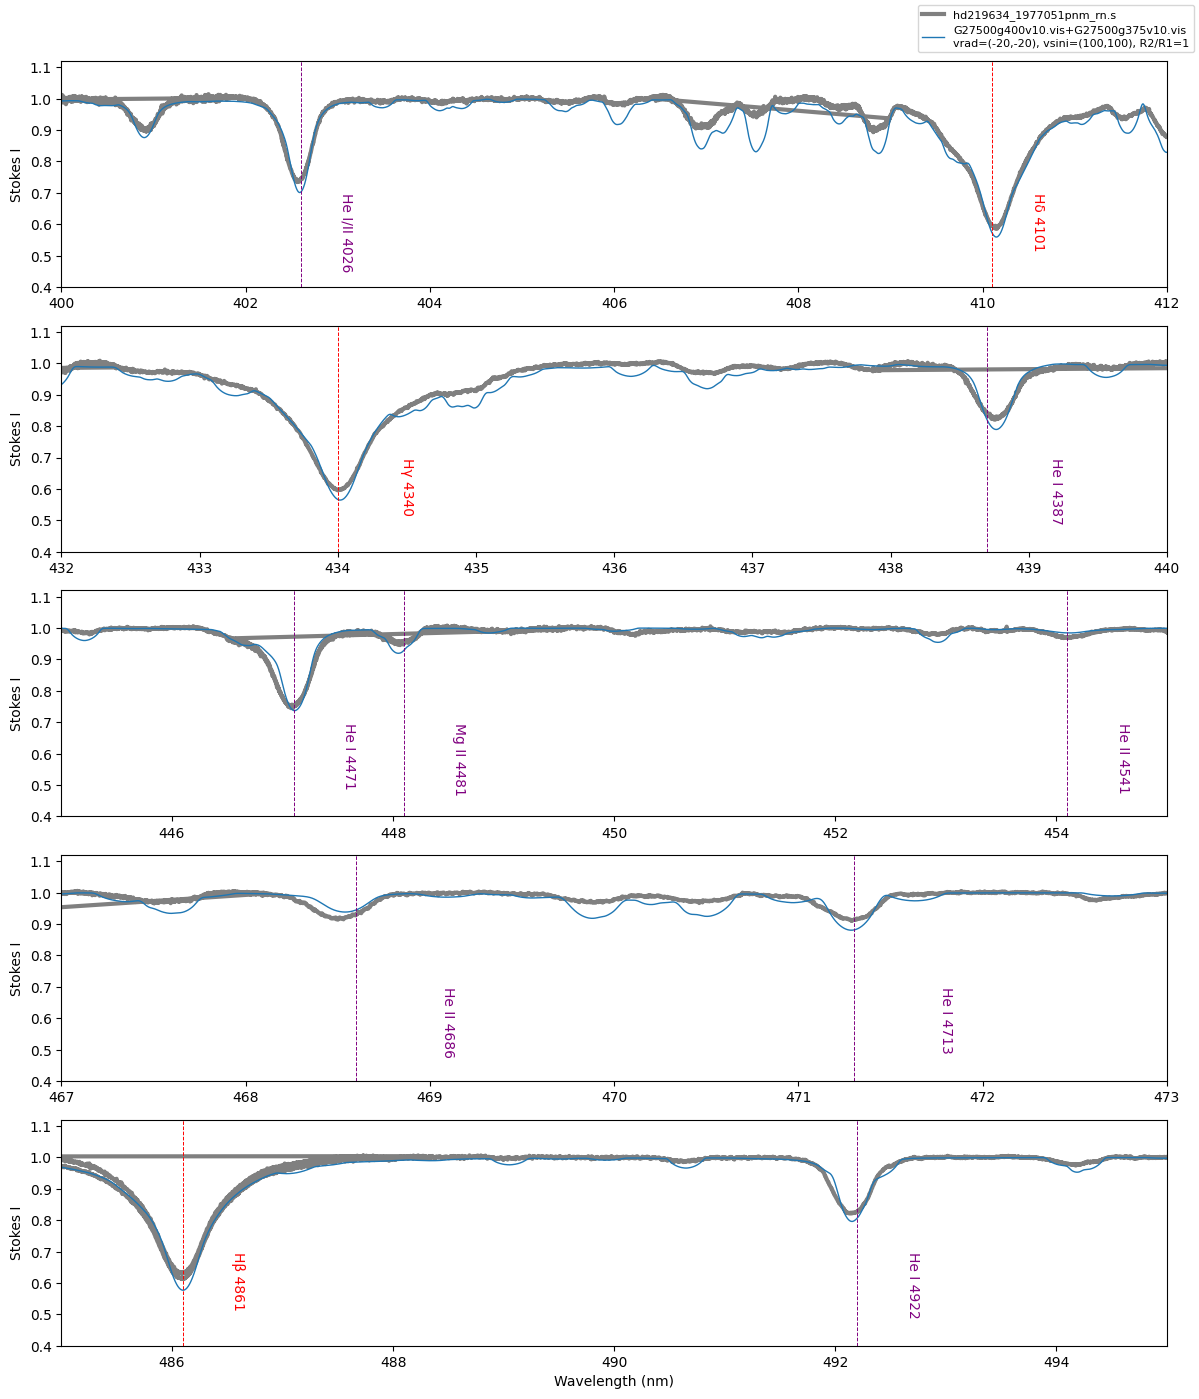

In [86]:
windows = [(400,412), (432,440), (445,455), (467,473), (485,495)]

lines_H = [(410.1, "Hδ 4101"),(434.0, "Hγ 4340"),(486.1, "Hβ 4861")]

lines_He = [(402.6, "He I/II 4026"),(420.0, "He II 4200"),(438.7, "He I 4387"),(447.1, "He I 4471"),
            (448.1, "Mg II 4481"),(454.1, "He II 4541"),(468.6, "He II 4686"),(471.3, "He I 4713"),(492.2, "He I 4922"),
            (501.6, "He I 5016"),(580.1,"CIV 5801"),(581.1,"CIV 5811")]

fig, ax = plt.subplots(len(windows), 1,figsize=(12, 2.8 * len(windows)))

for i, (xmin, xmax) in enumerate(windows):
    ax[i].plot(spec.wl, spec.specI, lw=3, color='grey', label=name)
    # ax[i].plot(model_A.wl/10, model_A.specI, lw=1,color='red', label=label_A)
    ax[i].plot(model_B.wl/10, model_B.specI, lw=1,label=label_B)
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.12)
    ax[i].set_ylabel("Stokes I")

    # Hydrogen lines
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='red', ls='--',lw=0.7)

            ax[i].text(wl + 0.5,0.70,label,color='red',fontsize=10,rotation=-90,ha='center',va='top')
    # Helium / metal lines
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='purple',ls='--',lw=0.7)
            ax[i].text(wl + 0.5,0.70,label,color='purple',fontsize=10,rotation=-90,ha='center',va='top')

ax[-1].set_xlabel("Wavelength (nm)")

# Only show legend once
handles, labels = ax[0].get_legend_handles_labels()


fig.legend(
    handles,
    labels,
    loc="upper right",
    fontsize=8
)

# fig.suptitle("Comparison of TLUSTY Models",fontsize=15,y=0.99)

fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

In [78]:
component_1, component_2, label_1, label_2 = make_binary_components(params_B)

save_binary_model(
    observation_name.replace("_rn.s", ""),
    params_B,
    component_1,
    component_2,
    model_B
)

Saved to G:\Shared drives\BinamicsOstars\TLUSTY Models\hd199081_N_149718pn


In [85]:
params_B = {
    "teff1": 32500, "logg1":425,
    "teff2": 32500, "logg2":425,
    "vsini1": 100, "vsini2": 100,
    "vrad1": 20, "vrad2":40,
    "R2R1":1,
    "vturb": 10,

}

model_B, label_B = make_binary_model_O(params_B)


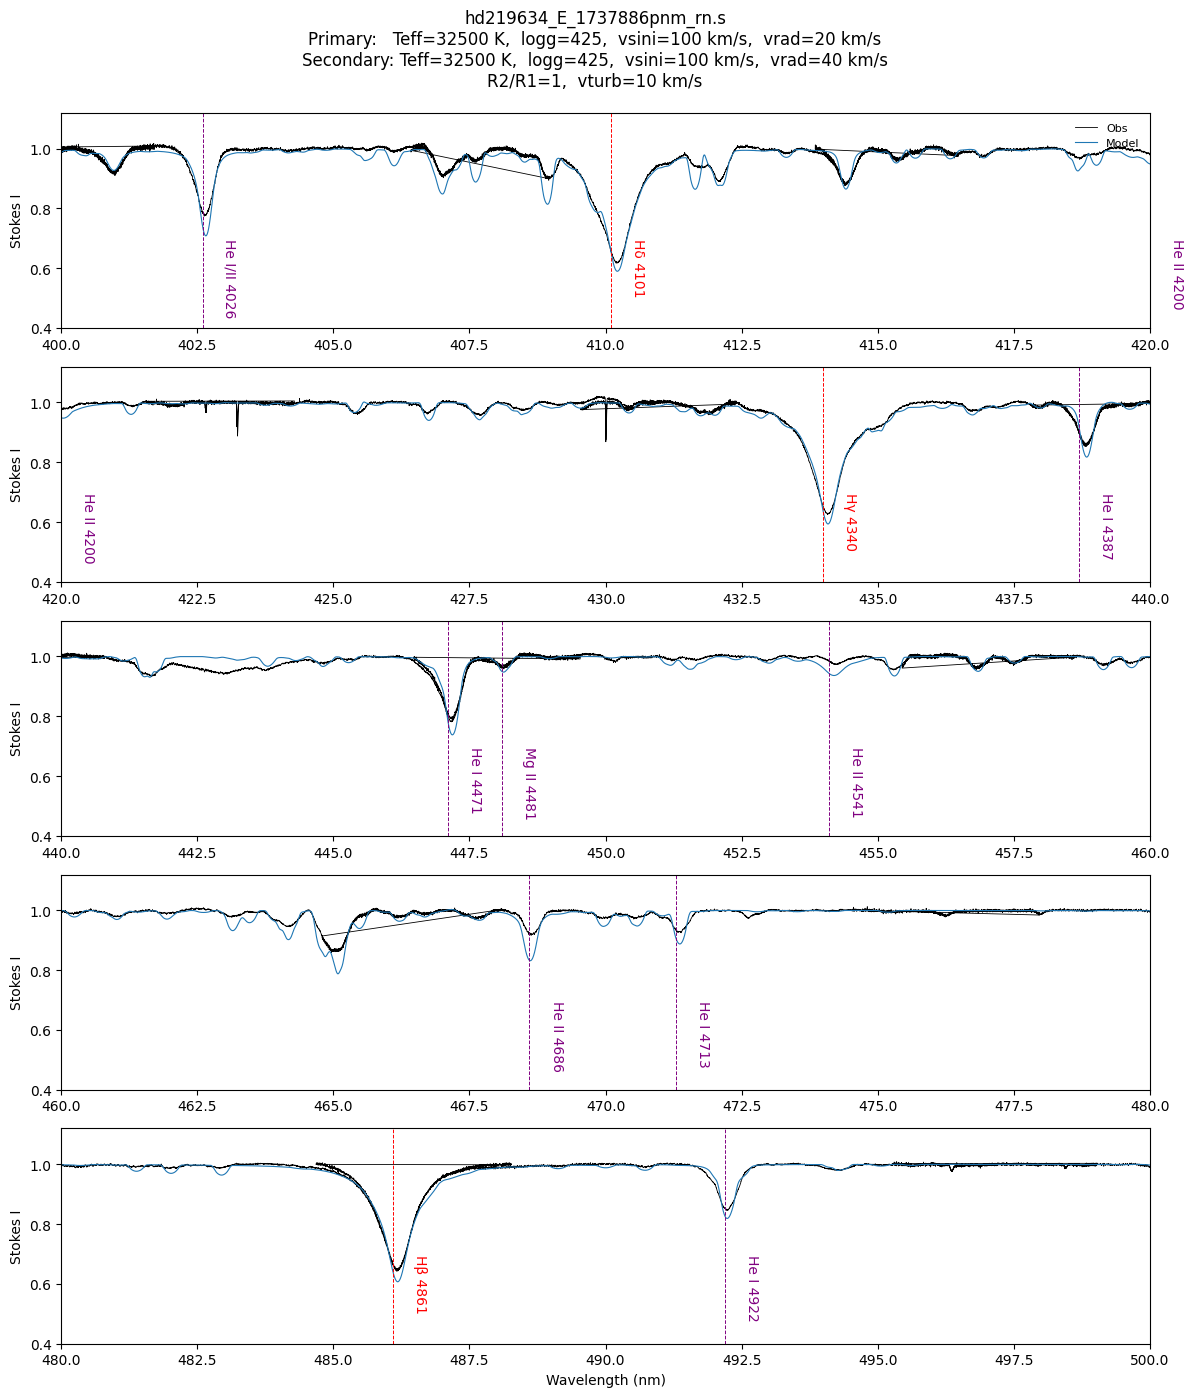

In [86]:
windows = [(400, 420),(420, 440),(440, 460),(460, 480),(480, 500)]

lines_H = [(410.1, "Hδ 4101"),(434.0, "Hγ 4340"),(486.1, "Hβ 4861")]

lines_He = [(402.6, "He I/II 4026"),(420.0, "He II 4200"),(438.7, "He I 4387"),(447.1, "He I 4471"),
            (448.1, "Mg II 4481"),(454.1, "He II 4541"),(468.6, "He II 4686"),(471.3, "He I 4713"),(492.2, "He I 4922"),
            (501.6, "He I 5016"),(580.1,"CIV 5801"),(581.1,"CIV 5811")]



# model_A, label_A = make_binary_model(params_A)

fig, ax = plt.subplots(len(windows), 1,figsize=(12, 2.8 * len(windows)))
param_text = (
    f"Primary:   Teff={params_B['teff1']} K,  logg={params_B['logg1']},  "
    f"vsini={params_B['vsini1']} km/s,  vrad={params_B['vrad1']} km/s\n"
    f"Secondary: Teff={params_B['teff2']} K,  logg={params_B['logg2']},  "
    f"vsini={params_B['vsini2']} km/s,  vrad={params_B['vrad2']} km/s\n"
    f"R2/R1={params_B['R2R1']},  vturb={params_B['vturb']} km/s"
)


for i, (xmin, xmax) in enumerate(windows):
    ax[i].plot(spec.wl, spec.specI, lw=0.6, color='k', label='Obs')
    ax[i].plot(model_B.wl/10, model_B.specI, lw=0.8, label='Model')
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.12)
    ax[i].set_ylabel("Stokes I")

    # Hydrogen lines
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='red', ls='--',lw=0.7)

            ax[i].text(wl + 0.5,0.70,label,color='red',fontsize=10,rotation=-90,ha='center',va='top')
    # Helium / metal lines
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='purple',ls='--',lw=0.7)
            ax[i].text(wl + 0.5,0.70,label,color='purple',fontsize=10,rotation=-90,ha='center',va='top')

ax[-1].set_xlabel("Wavelength (nm)")

# Only show legend once
handles, labels = ax[0].get_legend_handles_labels()


ax[0].legend(loc="upper right", fontsize=8, frameon=False)

fig.suptitle(
    f"{name}\n{param_text}",
    fontsize=12,
    y=0.995
)
fig.tight_layout()

plt.show()

In [30]:
print(obs)
name = obs[1]
spec = pol.read_spectrum(obs_folder / f"{name}")
params_B = {
    "grid_1":"B", "grid_2":"B",
    "teff1": 18000, "logg1":400,
    "teff2": 17000, "logg2":350,
    "vsini1": 50, "vsini2": 50,
    "vrad1": -30, "vrad2": 30,
    "R2R1":1.3,
    "vturb": 2,
}


['hd23625_2004924pnm_rn.s', 'hd23625_E_1650068pnm_rn.s', 'hd23625_E_2004924pnm_rn.s']


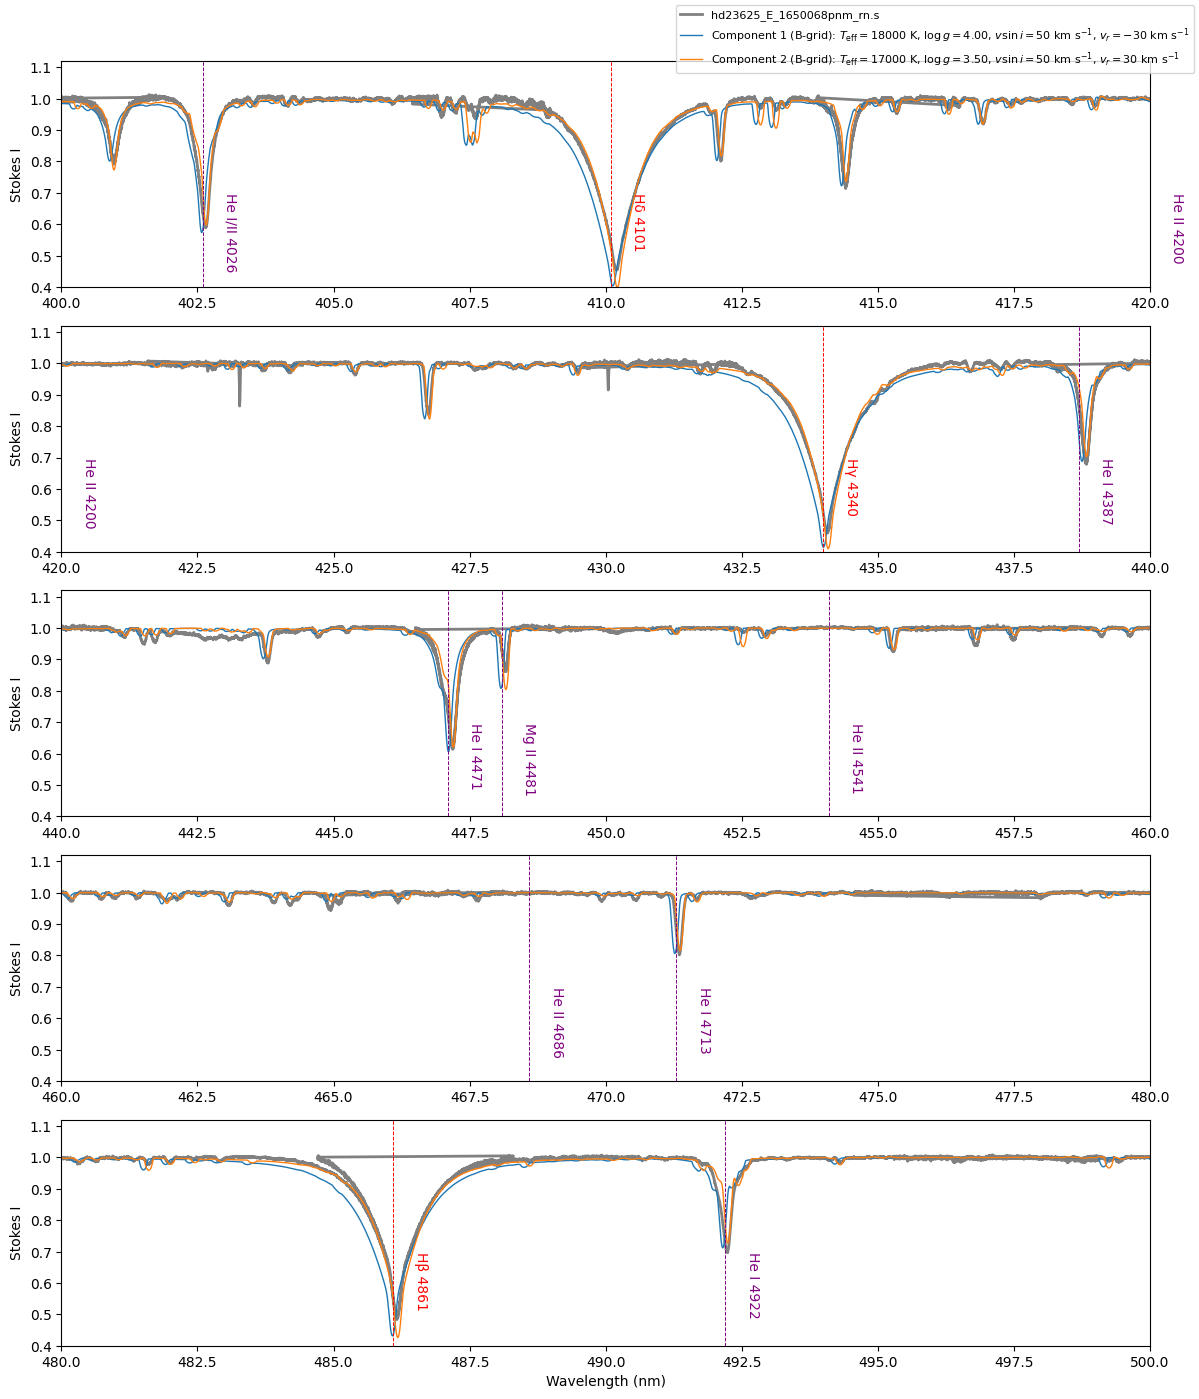

In [31]:
component_1, component_2, label_1, label_2 = (
    make_binary_components(params_B)
)
windows = [
    (400, 420),
    (420, 440),
    (440, 460),
    (460, 480),
    (480, 500)
]

lines_H = [
    (410.1, "Hδ 4101"),
    (434.0, "Hγ 4340"),
    (486.1, "Hβ 4861"),
]

lines_He = [
    (402.6, "He I/II 4026"),
    (420.0, "He II 4200"),
    (438.7, "He I 4387"),
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
    (492.2, "He I 4922"),
    (501.6, "He I 5016"),
    (580.1, "C IV 5801"),
    (581.1, "C IV 5811"),
]

# (
#     common_wl,
#     diluted_1,
#     diluted_2,
#     combined,
#     light_1,
#     light_2,
# ) = radius_weight_components(
#     component_1,
#     component_2,
#     params_B["R2R1"],
# )

fig, ax = plt.subplots(
    len(windows),
    1,
    figsize=(12, 2.8 * len(windows)),
)

for i, (xmin, xmax) in enumerate(windows):
    # Observed spectrum
    ax[i].plot(
        spec.wl,
        spec.specI,
        lw=2,
        color="grey",
        label=name,
    )

    # Separate stellar components
    ax[i].plot(
        component_1.wl / 10,
        component_1.specI,
        lw=1,
        label=label_1,
    )

    ax[i].plot(
        component_2.wl / 10,
        component_2.specI,
        lw=1,
        label=label_2,
    )
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.12)
    ax[i].set_ylabel("Stokes I")

    for wl, line_label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(
                wl,
                color="red",
                ls="--",
                lw=0.7,
            )
            ax[i].text(
                wl + 0.5,
                0.70,
                line_label,
                color="red",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top",
            )

    for wl, line_label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(
                wl,
                color="purple",
                ls="--",
                lw=0.7,
            )
            ax[i].text(
                wl + 0.5,
                0.70,
                line_label,
                color="purple",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top",
            )

ax[-1].set_xlabel("Wavelength (nm)")

handles, legend_labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="upper right",
    fontsize=8,
)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()